# 5교시 프로젝트 — 데이터로 파헤치는 히트곡의 비밀 🎧📊

> **사용법**
> - 🔵 **수업** = 강사와 함께 · 🟡 **셀프** = 집에서 직접 채우기(빈칸 `____`)
> - 정답본(`_solution`)에는 **실행 결과 + 💡해석**이 셀마다 있습니다.
> - 이 프로젝트의 목표는 '수업 중 완성'이 아니라 **집에서 한 번 더 직접 완주**하는 것!

---

## 🎬 오늘의 미션 — 음원 회사 데이터 분석가

여러분은 한 음악 스트리밍 회사의 데이터 분석가입니다. 기획팀장이 묻습니다.

> *"우리 다들 '신나고 빠른 곡이 인기 많다', '틱톡 때문에 곡이 짧아졌다',*
> *'K-pop은 템포가 빠르다' 고 믿잖아? 근데 **그거 진짜야?** 데이터로 확인해줘."*

오늘 우리는 **Spotify 글로벌 트랙 11.4만 곡**(114개 장르, BTS 포함)으로
이런 **'음악계 통념'을 데이터로 검증**합니다. 결과가 통념과 같을까요, 다를까요? 🤔

**오늘의 5단계**: 입수 → 정제(중복 제거) → 분포 보기 → 관계 분석 → K-pop/BTS 파헤치기 → 해석

## ① 입수 — 도구 + 한글 폰트 + 데이터  🔵

아래 셀로 도구·폰트·데이터를 준비합니다. Spotify 데이터는 **다운로드 없이** 깃허브에서 자동으로 받아옵니다(코랩 OK).

In [1]:
# === 데이터 로드 설정 (로컬/코랩 자동) ===
import os, urllib.request
DATA_BASE = "https://raw.githubusercontent.com/acho98/gunyang-data/main/"
def data_path(fname):
    for _p in ("../data/" + fname, "data/" + fname):
        if os.path.exists(_p):
            return _p
    return DATA_BASE + fname

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

def set_korean_font():
    _cands = ["../data/BMDOHYEON.ttf", "data/BMDOHYEON.ttf", "BMDOHYEON.ttf"]
    if not any(os.path.exists(p) for p in _cands):
        try: urllib.request.urlretrieve(DATA_BASE + "BMDOHYEON.ttf", "BMDOHYEON.ttf")
        except Exception: pass
    for p in _cands:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p)
                plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()
                plt.rcParams["axes.unicode_minus"] = False
                return
            except Exception: pass
    print("(안내) 한글 폰트 미발견 — 영문 라벨은 정상.")
set_korean_font()

df = pd.read_csv(data_path("spotify_tracks.csv"))
print("입수 완료! 크기:", df.shape)

입수 완료! 크기: (114000, 20)


💡 **해석**: **114,000행 × 20열**. 한 줄이 곡 하나이고, `tempo`(템포/BPM)·`energy`(에너지)·`danceability`(댄서빌리티)·`valence`(긍정도)·`popularity`(인기도 0~100)·`duration_ms`(길이) 같은 **Spotify가 측정한 음향 수치**가 들어 있습니다. 이게 우리의 분석 재료예요.

### 첫인상 — `head()` 로 눈으로 보기  🔵

In [2]:
df[["artists", "track_name", "track_genre", "popularity", "tempo", "energy", "danceability"]].head()

,artists,track_name,track_genre,popularity,tempo,energy,danceability
0,Gen Hoshino,Comedy,acoustic,73,87.917,0.4610,0.676
1,Ben Woodward,Ghost - Acoustic,acoustic,55,77.489,0.1660,0.420
2,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,76.332,0.3590,0.438
3,Kina Grannis,Can't Help Falling In Love,acoustic,71,181.740,0.0596,0.266
4,Chord Overstreet,Hold On,acoustic,82,119.949,0.4430,0.618


💡 **해석**: 아티스트·곡명·장르와 함께 음향 수치가 보입니다. `tempo`는 분당 박자수(BPM, 클수록 빠름), `energy`·`danceability`는 0~1 점수(클수록 강함), `popularity`는 0~100 인기 점수입니다. (※ 인기도는 실제 스트리밍 '횟수'가 아니라 Spotify의 0~100 인기 점수예요.)

## ② 정제 — 숨어 있는 중복 곡 제거  🔵

실제 데이터엔 항상 함정이 있습니다. 이 데이터는 **한 곡이 여러 장르에 중복** 수록돼 있어요
(예: 같은 곡이 'dance'와 'pop'에 동시에). 곡 단위로 분석하려면 **중복을 제거**해야 합니다.
먼저 중복이 얼마나 되는지 확인합니다.

In [3]:
print("전체 행 수      :", len(df))
print("고유한 곡(track_id):", df["track_id"].nunique())
print("중복된 행 수     :", len(df) - df["track_id"].nunique())

전체 행 수      : 114000
고유한 곡(track_id): 89741
중복된 행 수     : 24259


💡 **해석**: 전체 11.4만 행인데 **고유 곡은 89,741개** — 약 **2.4만 행이 중복**입니다! 이대로 평균을 내면 중복 곡이 여러 번 세어져 결과가 왜곡돼요. (3교시에서 배운 '정제'가 실전에서 이렇게 필요합니다.)

### 중복 제거 — 곡 단위 표 만들기  🟡
`drop_duplicates("track_id")` 로 곡 하나당 한 줄만 남긴 `songs` 표를 만드세요.
> 💡 힌트: `df.drop_duplicates("track_id")`

In [4]:
songs = df.drop_duplicates("track_id").copy()
print("곡 단위 표 크기:", songs.shape)

곡 단위 표 크기: (89741, 20)


💡 **해석**: 이제 `songs` 는 **89,741곡**, 곡마다 딱 한 줄입니다. 앞으로 **'곡 단위' 분석은 `songs`**, **'장르별' 분석은 원본 `df`**(한 곡이 여러 장르에 속하니까)를 씁니다. 이 구분이 중요해요!

## ③ 분포 보기 — 히스토그램으로 '보통'을 파악  🔵

분석의 시작은 **"보통 어떤 값인가"** 입니다. 곡들의 **템포(BPM)** 가 어디에 몰려 있는지 히스토그램으로 봅니다.

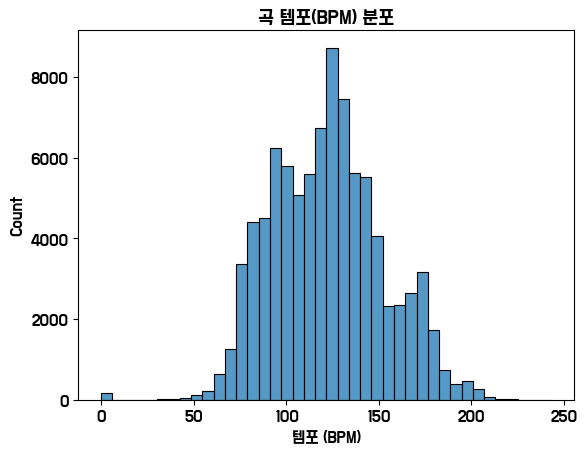

평균 템포: 122.1 BPM / 중앙값: 122.0


In [5]:
sns.histplot(data=songs, x="tempo", bins=40)
plt.title("곡 템포(BPM) 분포")
plt.xlabel("템포 (BPM)")
plt.show()
print("평균 템포:", round(songs["tempo"].mean(), 1), "BPM / 중앙값:", round(songs["tempo"].median(), 1))

💡 **해석**: 대부분의 곡이 **100~140 BPM** 에 몰려 있고, 평균 약 **122 BPM** 입니다. 봉우리가 120 부근에 크게 있죠 — 대중음악의 '국룰 템포'라 할 만합니다. 이렇게 **분포를 먼저 보면** 다음 분석의 기준이 잡힙니다.

### 직접 그려보기 — 댄서빌리티 분포  🟡
곡의 **댄서빌리티(`danceability`, 0~1 춤추기 좋은 정도)** 분포를 히스토그램으로 그려보세요.
> 💡 힌트: `sns.histplot(data=songs, x="danceability")`

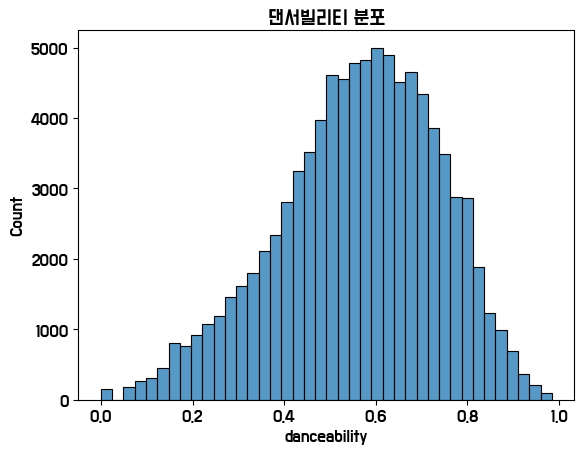

평균 댄서빌리티: 0.562


In [6]:
sns.histplot(data=songs, x="danceability", bins=40)
plt.title("댄서빌리티 분포")
plt.show()
print("평균 댄서빌리티:", round(songs["danceability"].mean(), 3))

💡 **해석**: 댄서빌리티는 **0.5~0.7** 부근에 봉긋하게 몰려, 좌우로 퍼진 종 모양에 가깝습니다(평균 약 0.56). 0에 가까운 곡(클래식 등)도, 0.9 넘는 곡(댄스곡)도 소수지만 존재하죠. **히스토그램 한 장으로 '전체 분포'가 한눈에** — 초급 분석의 핵심 무기입니다.

## ④ 관계 분석 (1) — "신나는 곡이 인기 많다"는 진짜일까?  🔵 (통념 검증 1)

팀장님의 첫 번째 통념: *"에너지 넘치고 춤추기 좋은 곡이 인기 많다."*
정말일까요? **댄서빌리티(x) ↔ 인기도(y)** 산점도로 확인합니다.

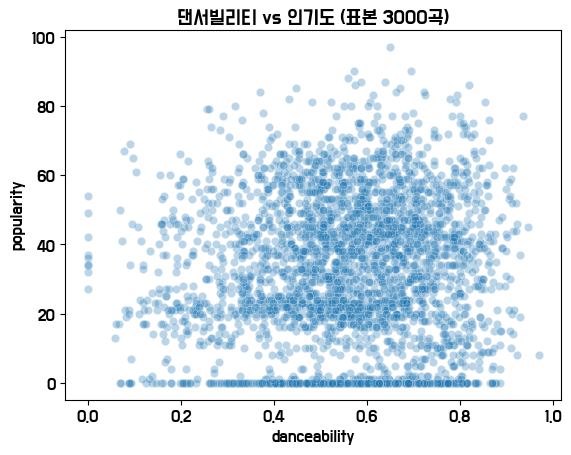

상관계수(댄서빌리티-인기도): 0.064


In [7]:
sns.scatterplot(data=songs.sample(3000, random_state=1), x="danceability", y="popularity", alpha=0.3)
plt.title("댄서빌리티 vs 인기도 (표본 3000곡)")
plt.show()
print("상관계수(댄서빌리티-인기도):", round(songs["danceability"].corr(songs["popularity"]), 3))

💡 **해석**: 점들이 **특정 방향 없이 구름처럼 흩어져** 있습니다. 상관계수도 **약 0.06** — 거의 0! 즉 *"춤추기 좋은 곡이라고 더 인기 있는 건 아니다."* 통념이 **빗나갔습니다.** (1교시 '상관관계' 기억나죠? 0에 가까우면 관계가 거의 없다는 뜻.)

### 그럼 다른 수치들은? — 인기도와의 상관 한 번에  🟡
여러 음향 수치와 `popularity` 의 상관계수를 한 번에 봅니다. 빈칸에 `popularity` 를 넣어 완성하세요.
> 💡 힌트: `songs[cols].corr()["popularity"]`

In [8]:
cols = ["popularity", "danceability", "energy", "valence", "tempo", "loudness", "duration_ms"]
songs[cols].corr()["popularity"].round(3)

popularity      1.000
danceability    0.064
energy          0.014
valence        -0.012
tempo           0.007
loudness        0.072
duration_ms    -0.023
Name: popularity, dtype: float64

💡 **해석**: 충격! 모든 음향 수치의 상관이 **−0.04 ~ +0.07** — 전부 **거의 0** 입니다. 에너지도, 템포도, 길이도 인기도와 **별 관계가 없어요.**
👉 결론: *"히트곡은 음향 수치만으로 설명되지 않는다."* 인기는 곡 자체보다 **아티스트·마케팅·타이밍·운** 같은 **데이터 밖 요인**이 크다는 뜻. — 1교시의 **"상관관계 ≠ 인과관계, 그리고 데이터에 없는 변수"** 가 여기서 살아납니다.

## ④ 관계 분석 (2) — "틱톡 때문에 짧은 곡이 인기"는 진짜일까?  🟡 (통념 검증 2)

두 번째 통념: *"요즘은 틱톡 영향으로 **짧은 곡**이 인기 많다."*
먼저 곡 길이를 **분(minute)** 으로 바꿔 분포를 보고, **짧은 곡 vs 긴 곡**의 평균 인기도를 비교합니다.
> 💡 힌트: 길이(분) = `duration_ms / 60000`

In [9]:
songs["분"] = songs["duration_ms"] / 60000
print("평균 곡 길이:", round(songs["분"].mean(), 2), "분 / 중앙값:", round(songs["분"].median(), 2), "분")

short = songs[songs["분"] < 3]["popularity"].mean()
long_ = songs[songs["분"] > 4]["popularity"].mean()
print(f"3분 미만 곡 평균 인기도: {short:.1f}")
print(f"4분 초과 곡 평균 인기도: {long_:.1f}")

평균 곡 길이: 3.82 분 / 중앙값: 3.55 분
3분 미만 곡 평균 인기도: 31.6
4분 초과 곡 평균 인기도: 32.7


💡 **해석**: 평균 곡 길이는 약 **3.8분**. 그런데 **3분 미만 곡(인기 31.6)이 4분 초과 곡(인기 32.7)보다 오히려 살짝 낮습니다!** 즉 이 데이터에선 *"짧은 곡이 더 인기"* 라는 통념이 **성립하지 않아요.** (앞의 상관계수에서도 길이-인기 상관은 −0.02로 거의 0이었죠.)

> 📌 **솔직한 한계**: 이 데이터엔 **발매 연도**가 없어서 "해마다 곡이 짧아졌는지"의 *시간 변화*는 볼 수 없습니다.
> 그래서 우리는 "길이 ↔ 인기" 관계로 통념을 **간접 검증**했어요. *"어떤 데이터로 무엇까지 말할 수 있는가"* 를 아는 것도 분석가의 실력입니다.

## ④ 관계 분석 (3) — 장르마다 '음향 지문'이 있다  🔵

음향 수치가 인기는 못 가르지만, **장르의 색깔**은 또렷하게 보여줍니다.
대표 장르 5개의 **에너지(`energy`)** 분포를 **박스플롯**으로 비교합니다.

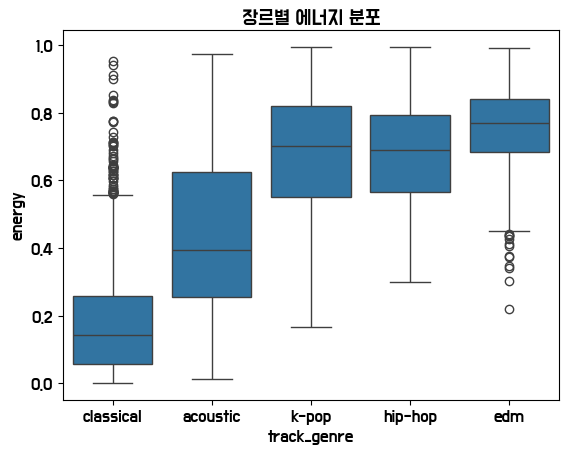

In [10]:
genres = ["classical", "acoustic", "k-pop", "hip-hop", "edm"]
sub = df[df["track_genre"].isin(genres)]
sns.boxplot(data=sub, x="track_genre", y="energy", order=genres)
plt.title("장르별 에너지 분포")
plt.show()

💡 **해석**: 왼쪽(클래식·어쿠스틱)은 에너지가 **낮고**, 오른쪽(힙합·EDM)으로 갈수록 **확 높아집니다**(클래식 0.19 → EDM 0.76). K-pop은 그 중간(약 0.68)이고요. 박스플롯 한 장으로 **"장르마다 에너지 지문이 다르다"** 가 선명하죠. 이게 분포 비교의 힘입니다.

### 직접 비교 — 장르별 템포  🟡
같은 5개 장르의 **템포(`tempo`)** 분포를 박스플롯으로 비교해보세요.
> 💡 힌트: `sns.boxplot(data=sub, x="track_genre", y="tempo", order=genres)`

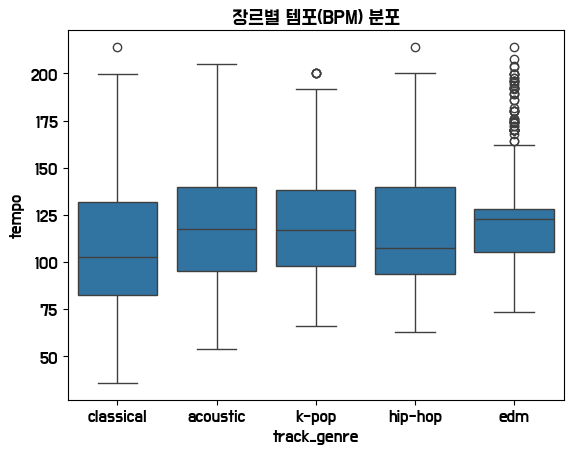

In [11]:
sns.boxplot(data=sub, x="track_genre", y="tempo", order=genres)
plt.title("장르별 템포(BPM) 분포")
plt.show()

💡 **해석**: 템포는 에너지만큼 장르 차이가 크진 않지만, EDM(약 122)이 가장 빠르고 클래식(약 108)이 느린 편입니다. **K-pop은 약 119 BPM** — 의외로 가장 빠른 축이 아니죠? 이 단서가 다음 파트의 핵심이 됩니다. 👀

## ⑤ 하이라이트 — "K-pop은 템포가 빠르다"는 진짜일까? 🇰🇷  🔵 (통념 검증 3)

마지막 통념: *"K-pop은 신나고 빠른 곡이 많다."* 우리의 직감이죠.
**K-pop 장르의 평균 템포 vs 전체 평균 템포** 를 직접 비교합니다.

In [12]:
kpop = df[df["track_genre"] == "k-pop"]
print(f"전체 평균 템포 : {df['tempo'].mean():.1f} BPM")
print(f"K-pop 평균 템포: {kpop['tempo'].mean():.1f} BPM")
print(f"K-pop 평균 인기도: {kpop['popularity'].mean():.1f}  (114개 장르 중 인기 2위!)")

전체 평균 템포 : 122.1 BPM
K-pop 평균 템포: 119.2 BPM
K-pop 평균 인기도: 56.9  (114개 장르 중 인기 2위!)


💡 **해석**: 반전! **K-pop 템포(119 BPM) < 전체 평균(122 BPM)** — K-pop은 오히려 **약간 느린** 편입니다! "빠르다"는 통념이 또 빗나갔어요.
하지만 **인기도는 56.9로 114개 장르 중 2위** — *느린 게 아니라, 빠르지 않아도 압도적으로 인기 있다*는 게 진실입니다. 👉 **"인기 ≠ 빠른 템포"**.

### 직접 파헤치기 — BTS 곡들의 음향 프로필  🟡
이 데이터엔 **BTS 곡**도 있습니다! BTS 곡만 골라(중복 제거) 평균 음향 수치를 구해보세요.
> 💡 힌트: 문자열 포함 검색 `songs["artists"].str.contains("BTS")`

In [13]:
bts = songs[songs["artists"].str.contains("BTS", case=False, na=False)]
print("데이터 속 BTS 곡 수:", len(bts))
print(bts[["tempo", "energy", "danceability", "popularity"]].mean().round(2))

데이터 속 BTS 곡 수: 170
tempo           122.04
energy            0.75
danceability      0.63
popularity       67.36
dtype: float64


💡 **해석**: BTS 곡 약 **170곡**, 평균 **템포 122·에너지 0.75·댄서빌리티 0.63·인기도 67.4**. 에너지는 높지만(0.75) 템포는 글로벌 평균(122)과 **똑같은 수준**이고, **인기도 67.4는 전체 곡 평균(약 33)의 두 배가 넘습니다!** 역시 "빠름"이 아니라 "높은 완성도+팬덤"이 인기의 비결이라는 걸 데이터가 보여주죠.

## ⑥ 해석 — 팀장님께 보고서 한 문단  🟡

오늘 검증한 통념 3개의 결과를 **한 번에 출력**하고, 맨 아래 `[보고]` 에 **내 결론을 한 문단** 적어보세요.

In [14]:
print("=== 음악계 통념, 데이터로 검증한 결과 ===")
print(f"통념1 '신나는 곡이 인기' → 댄서빌리티-인기 상관 {songs['danceability'].corr(songs['popularity']):.2f} (거의 무관) ❌")
print(f"통념2 '짧은 곡이 인기'   → 3분미만 {songs[songs['분']<3]['popularity'].mean():.1f} vs 4분초과 {songs[songs['분']>4]['popularity'].mean():.1f} (오히려 긴 곡↑) ❌")
print(f"통념3 'K-pop은 빠르다'   → K-pop {df[df.track_genre=='k-pop']['tempo'].mean():.0f} vs 전체 {df['tempo'].mean():.0f} BPM (오히려 느림) ❌")
print()
print("[보고] 세 통념 모두 데이터에서 성립하지 않았다. 음향 수치는 인기를 거의 설명하지 못했고,")
print("       인기는 곡 밖의 요인(아티스트·팬덤·마케팅)에 더 크게 좌우되는 것으로 보인다.")

=== 음악계 통념, 데이터로 검증한 결과 ===
통념1 '신나는 곡이 인기' → 댄서빌리티-인기 상관 0.06 (거의 무관) ❌
통념2 '짧은 곡이 인기'   → 3분미만 31.6 vs 4분초과 32.7 (오히려 긴 곡↑) ❌
통념3 'K-pop은 빠르다'   → K-pop 119 vs 전체 122 BPM (오히려 느림) ❌

[보고] 세 통념 모두 데이터에서 성립하지 않았다. 음향 수치는 인기를 거의 설명하지 못했고,
       인기는 곡 밖의 요인(아티스트·팬덤·마케팅)에 더 크게 좌우되는 것으로 보인다.


💡 **모범 보고**: *"세 가지 음악계 통념 — '신나는 곡이 인기', '짧은 곡이 인기', 'K-pop은 빠르다' — 은 이 데이터에서 **모두 성립하지 않았다.** 음향 수치(에너지·댄서빌리티·템포·길이)와 인기도의 상관은 전부 0에 가까웠고, K-pop은 오히려 평균보다 느린데도 인기 2위 장르였다. 결론적으로 **히트곡은 음향 수치로 예측되지 않으며**, 인기는 곡 자체보다 아티스트·팬덤·타이밍 같은 데이터 밖 요인에 더 좌우된다."*

데이터가 **상식을 뒤집는** 걸 직접 확인했습니다. 이게 분석의 진짜 가치예요.

## 🎉 수고하셨습니다 — '통념 파괴' 분석 완주!

오늘 여러분은 11.4만 곡으로 **세 가지 음악계 통념을 데이터로 검증**했고, **셋 다 틀렸다**는 걸 직접 밝혀냈습니다.

```
 ① 입수      ② 정제          ③ 분포          ④ 관계분석          ⑤ 해석
11.4만곡 →  중복 2.4만 제거 → 히스토그램 →  산점도·상관·박스플롯 →  "통념은 틀렸다"
```

**오늘의 가장 큰 교훈**:
> 우리가 '당연하다'고 믿던 것(신나는 곡=인기, 짧은 곡=인기, K-pop=빠름)이 **데이터 앞에서 줄줄이 무너졌습니다.**
> AI에게 "히트곡 공식 알려줘"라고 물으면 그럴듯한 답을 줄 거예요. 하지만 **"진짜야?" 하고 데이터로 따져보는 것** — 그게 분석가의 일입니다.

> ## "도구는 변해도, 좋은 질문을 던지고 결과를 해석하는 힘은 사람의 몫이다."

> 🏠 **셀프스터디**: 이 데이터로 또 다른 통념을 직접 검증해보세요.
> 예) "슬픈 곡(`valence` 낮음)이 더 인기 있을까?", "내가 좋아하는 아티스트의 음향 프로필은?" — 방법은 오늘과 똑같습니다! 🚀